# Example analysis: three sources, one catalog

A worked tour of the astrolabe pipeline, live against the real services:

1. **Gaia DR3** — cone search on the Pleiades, persisted through the `Store`,
   then an HR (colour–magnitude) diagram of the cluster members.
2. **Gaia × SDSS** — both surveys queried on the same equatorial field, cross-matched
   positionally at 1 arcsec, and the photometry compared.
3. **JPL Horizons** — a year of Mars ephemerides, plotted as a sky track and a
   distance/brightness curve tracing the run-up to the early-2027 opposition.

Everything fetched lands in `data/` via `astrolabe.store.Store` (Parquet + sidecar
metadata), and the last section queries it all back with DuckDB SQL. Requires network;
a full run takes a couple of minutes, dominated by the Gaia TAP job.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from astrolabe.analysis import crossmatch, hr_diagram
from astrolabe.sources import get_source
from astrolabe.store import Store

# Root the store at the repo's data/ directory regardless of where the kernel runs.
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
store = Store(root / "data")
store.data_dir

PosixPath('/Users/daniel/workspace/constellation/codebases/astrolabe/data')

## 1. Gaia — the Pleiades

A 1.5° cone around the cluster centre. The adapter builds the ADQL, runs it against
the ESA TAP service, and hands back an astropy `Table` already carrying the house
standard columns (`source_id`, `ra`, `dec`) plus Gaia photometry and parallax.

In [2]:
PLEIADES = {"ra": 56.75, "dec": 24.1167, "radius": 1.5, "limit": 8000}

gaia = get_source("gaia")
pleiades = gaia.query(PLEIADES)
print(f"{len(pleiades)} rows")
pleiades[:5]

INFO: Query finished. [astroquery.utils.tap.core]
8000 rows


source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax
,deg,deg,mag,mag,mas
int64,float64,float64,float32,float32,float64
64035419763044096,56.951057272430546,22.646238621849175,17.251532,1.0519676,0.48553795471289457
64127439440404096,57.20779005161047,22.690317231568148,19.102081,1.1028099,0.23277147422128
64130875412657792,57.18879746804258,22.74849767028636,20.721712,2.1305523,--
64131356448910080,57.10966816542592,22.744545916802043,20.687,1.3699417,-1.485686602375731
64132902638779136,57.35958701437275,22.736955607530014,19.066645,1.2198181,0.08857902740419006


In [3]:
meta = store.write(pleiades, name="pleiades_gaia", source="gaia", query=PLEIADES)
meta

DatasetMeta(name='pleiades_gaia', source='gaia', query={'ra': 56.75, 'dec': 24.1167, 'radius': 1.5, 'limit': 8000}, fetched_at='2026-07-10T04:44:21.898276+00:00', n_rows=8000, columns=['source_id', 'ra', 'dec', 'phot_g_mean_mag', 'bp_rp', 'parallax'])

### HR diagram

The Pleiades sit at ~136 pc (parallax ≈ 7.4 mas), so a parallax window separates
cluster members from the fore/background. Left: every star in the field with a
usable parallax. Right: the members only — the cluster's main sequence pops out.

82 of 8000 stars in the parallax window (6.5–8.5 mas)


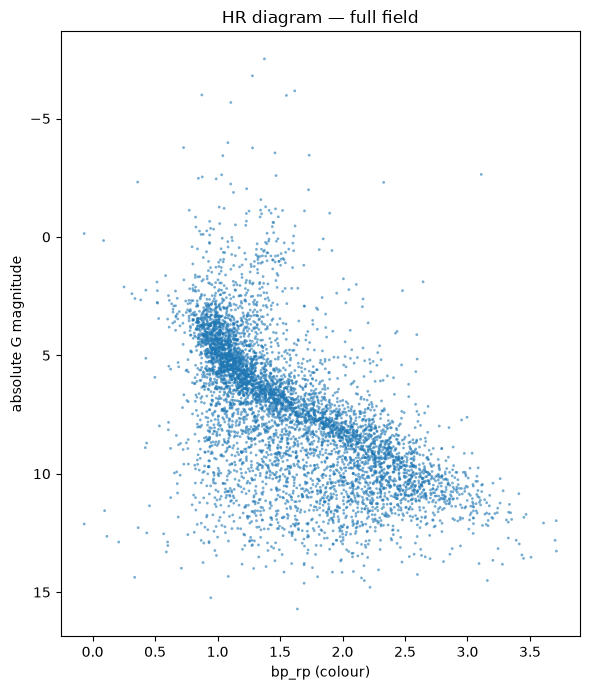

In [4]:
parallax = np.asarray(pleiades["parallax"], dtype=float)
member_mask = (parallax > 6.5) & (parallax < 8.5)
members = pleiades[member_mask]
print(f"{member_mask.sum()} of {len(pleiades)} stars in the parallax window (6.5–8.5 mas)")

fig_field = hr_diagram(pleiades)
fig_field.axes[0].set_title("HR diagram — full field")
fig_field

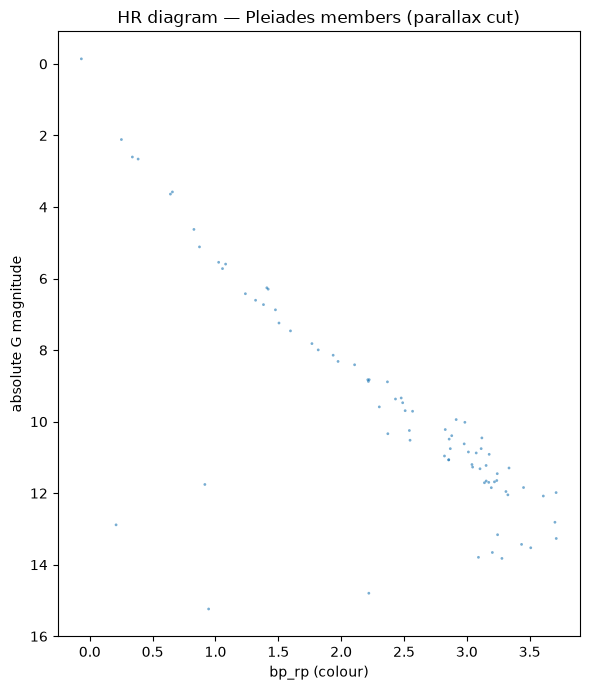

In [5]:
fig_members = hr_diagram(members)
fig_members.axes[0].set_title("HR diagram — Pleiades members (parallax cut)")
fig_members

## 2. Gaia × SDSS cross-match

The Pleiades are outside the SDSS footprint, so for the cross-match we pick a small
field on the celestial equator (well inside SDSS coverage) and query **both** surveys
over it. `crossmatch` then pairs each Gaia star with its nearest SDSS object within
1 arcsec — the standard sanity check that two catalogs are talking about the same sky.

> **Workaround (2026-07):** astroquery's SDSS module currently gets an HTML error page
> back from SkyServer's `x_results.aspx` endpoint (both 0.4.11 and dev), while
> SkyServer's REST API (`SkyServerWS/SearchTools/SqlSearch`) works fine. The adapter's
> `_run_sql` is the designed injection seam (tests use it for fixtures), so we point it
> at the working REST endpoint here — the data is still live SDSS DR17, and the
> adapter's normalization (`objid -> source_id`) still runs.

In [6]:
import requests
from astropy.table import Table


def _skyserver_sql(sql: str) -> Table:
    """Live SDSS DR17 SQL via the SkyServer REST API (see workaround note above)."""
    resp = requests.get(
        "https://skyserver.sdss.org/dr17/SkyServerWS/SearchTools/SqlSearch",
        params={"cmd": sql, "format": "csv"},
        timeout=60,
    )
    resp.raise_for_status()
    return Table.read(resp.text, format="ascii.csv", comment="#")


sdss = get_source("sdss")
sdss._run_sql = _skyserver_sql  # inject the working fetcher through the seam

In [7]:
FIELD = {"ra": 180.0, "dec": 0.0, "radius": 0.02}  # ~72 arcsec cone on the equator

sdss_field = sdss.query(
    {
        "sql": f"""
        SELECT p.objid, p.ra, p.dec, p.u, p.g, p.r, p.i, p.z
        FROM PhotoObj p
        JOIN dbo.fGetNearbyObjEq({FIELD["ra"]}, {FIELD["dec"]}, {FIELD["radius"] * 60}) n
          ON p.objID = n.objID
        """
    }
)
gaia_field = gaia.query({**FIELD, "limit": 2000})
print(f"SDSS: {len(sdss_field)} objects, Gaia: {len(gaia_field)} objects")
sdss_field[:5]

INFO: Query finished. [astroquery.utils.tap.core]
SDSS: 41 objects, Gaia: 8 objects


source_id,ra,dec,u,g,r,i,z
int64,float64,float64,float64,float64,float64,float64,float64
1237648721230758388,179.998277943308,-0.00210475908868588,23.98372,21.82411,20.41531,19.90866,19.53479
1237648721230759016,179.991404847481,-0.000620867491497155,23.18021,23.79184,22.81934,21.93592,22.1139
1237648721230758376,179.993428358791,-0.00102306427697289,24.55911,22.85571,22.40711,22.10345,21.97826
1237648721230757902,179.983457589033,-0.00159469259995855,20.69708,19.1523,18.40487,17.96642,17.7226
1237648721230757900,179.984556919786,-0.00103185177466127,18.32745,17.04759,16.78409,16.69269,16.65998


In [8]:
matched = crossmatch(gaia_field, sdss_field, radius_arcsec=1.0)
print(f"{len(matched)} Gaia stars matched to an SDSS object within 1 arcsec")
matched[:5]

8 Gaia stars matched to an SDSS object within 1 arcsec


source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,source_id_2,ra_2,dec_2,u,g,r,i,z,sep_arcsec
,deg,deg,mag,mag,mas,,,,,,,,,
int64,float64,float64,float32,float32,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64
3795033274544636416,179.98510968444862,-0.00452338031708756,18.29871,1.6347752,0.6285345769077572,1237648721230757996,179.985177608229,-0.00448163945990874,22.25248,19.43954,18.2672,17.7875,17.47975,0.28700691694980646
3602879603113628416,180.0112053206381,-0.01303815699336296,13.043417,0.78474426,1.3140678130168668,1237648721230757913,180.011193736081,-0.0130192693811558,15.47299,13.86942,13.16425,13.09265,13.84864,0.07976611006734521
3602879667537000192,179.9982823938733,-0.002115523265182086,21.375732,1.6050014,--,1237648721230758388,179.998277943308,-0.00210475908868588,23.98372,21.82411,20.41531,19.90866,19.53479,0.041932664470102715
3891110151063107968,179.9860111926941,0.014272031247245812,20.811264,0.70687103,--,1237674650465534778,179.986016439666,0.0142613532614684,22.44692,22.13788,20.81608,20.69154,20.63519,0.04283093744417082
3795033278840733568,179.98454466723103,-0.0010407656218980835,16.626635,0.6764889,-0.025869121274598644,1237648721230757900,179.984556919786,-0.00103185177466127,18.32745,17.04759,16.78409,16.69269,16.65998,0.054547042206704456


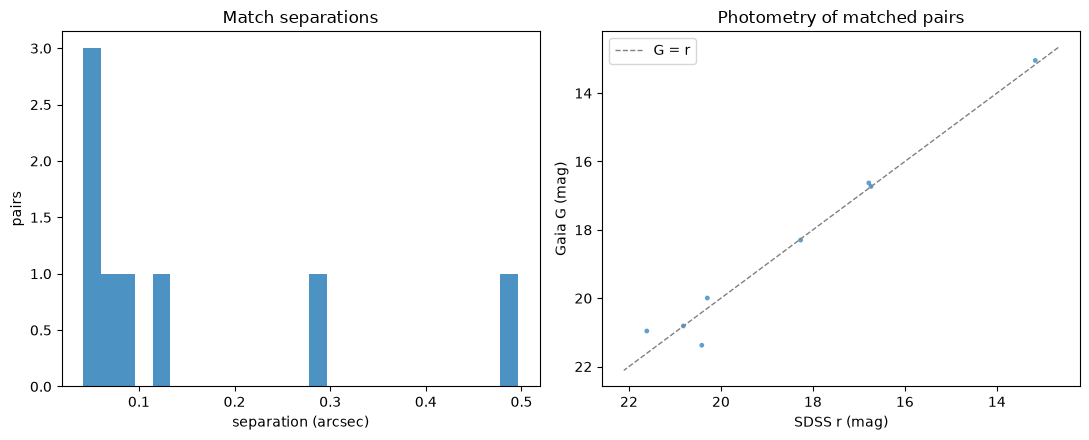

In [9]:
store.write(gaia_field, name="field_eq180_gaia", source="gaia", query={**FIELD, "limit": 2000})
store.write(sdss_field, name="field_eq180_sdss", source="sdss", query=FIELD)
store.write(
    matched,
    name="field_eq180_xmatch",
    kind="derived",  # a product of analysis/, not a fetch
    source="analysis.crossmatch",
    query={**FIELD, "radius_arcsec": 1.0},
    lineage=[{"dataset": "field_eq180_gaia"}, {"dataset": "field_eq180_sdss"}],
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.hist(matched["sep_arcsec"], bins=25, color="tab:blue", alpha=0.8)
ax1.set_xlabel("separation (arcsec)")
ax1.set_ylabel("pairs")
ax1.set_title("Match separations")

g = np.asarray(matched["phot_g_mean_mag"], dtype=float)
r = np.asarray(matched["r"], dtype=float)
ax2.scatter(r, g, s=12, alpha=0.7, edgecolors="none")
lo, hi = np.nanmin(r) - 0.5, np.nanmax(r) + 0.5
ax2.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1, label="G = r")
ax2.set_xlabel("SDSS r (mag)")
ax2.set_ylabel("Gaia G (mag)")
ax2.set_title("Photometry of matched pairs")
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.legend()
fig.tight_layout()

The separation histogram should pile up well below 1 arcsec (real matches), and Gaia G
tracks SDSS r closely since the G band broadly overlaps r — points scatter around the
G = r line with colour-dependent offsets.

## 3. JPL Horizons — a year of Mars

Ephemerides are time-series rather than a static catalog, so the adapter is thin: it
returns Horizons' table normalized to carry `ra`/`dec` and a `source_id` equal to the
target id. We pull geocentric positions for Mars through 2026 at a 3-day cadence.

In [10]:
MARS_QUERY = {
    "target": "499",  # Mars barycenter
    "location": "500@399",  # geocentric
    "epochs": {"start": "2026-01-01", "stop": "2026-12-31", "step": "3d"},
}

horizons = get_source("horizons")
mars = horizons.query(MARS_QUERY)
print(f"{len(mars)} epochs, columns include: {mars.colnames[:12]} ...")

# Keep a tidy subset for storage: position, brightness, and distances.
mars_slim = mars["source_id", "datetime_str", "datetime_jd", "ra", "dec", "V", "delta", "r"]
store.write(mars_slim, name="mars_2026", source="horizons", kind=horizons.kind, query=MARS_QUERY)
mars_slim[:5]

122 epochs, columns include: ['targetname', 'datetime_str', 'datetime_jd', 'solar_presence', 'lunar_presence', 'ra', 'dec', 'RA_app', 'DEC_app', 'RA_rate', 'DEC_rate', 'AZ'] ...


source_id,datetime_str,datetime_jd,ra,dec,V,delta,r
,---,d,deg,deg,mag,AU,AU
str3,str17,float64,float64,float64,float64,float64,float64
499,2026-Jan-01 00:00,2461041.5,283.48904,-23.75166,1.072,2.41069876736921,1.428708512639
499,2026-Jan-04 00:00,2461044.5,285.9906,-23.53707,1.05,2.40826166609343,1.42564020088
499,2026-Jan-07 00:00,2461047.5,288.48974,-23.28264,1.029,2.40567296545184,1.422649784527
499,2026-Jan-10 00:00,2461050.5,290.985,-22.9887,1.005,2.40293689614952,1.419740521181
499,2026-Jan-13 00:00,2461053.5,293.47488,-22.6557,1.045,2.40005499793577,1.416915617716


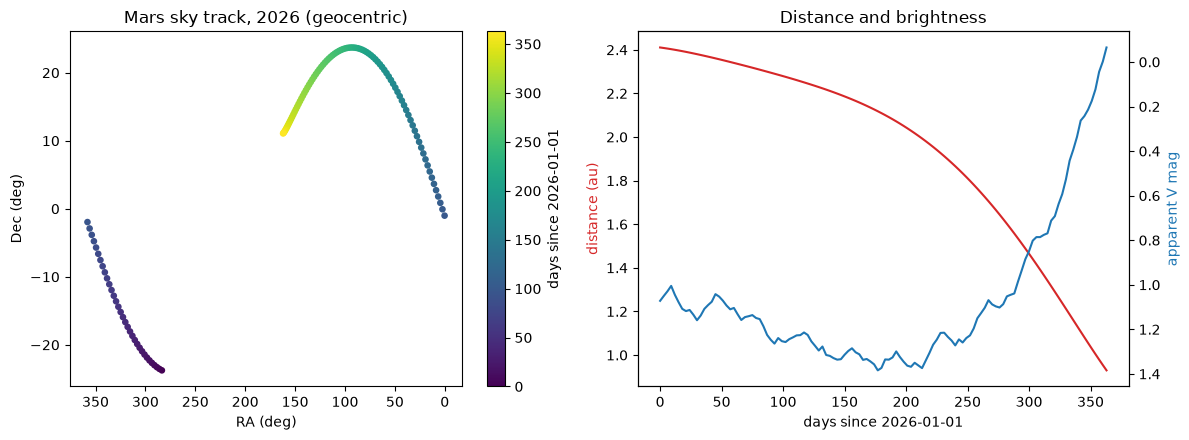

In [11]:
jd = np.asarray(mars_slim["datetime_jd"], dtype=float)
days = jd - jd[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sc = ax1.scatter(mars_slim["ra"], mars_slim["dec"], c=days, cmap="viridis", s=14)
ax1.set_xlabel("RA (deg)")
ax1.set_ylabel("Dec (deg)")
ax1.set_title("Mars sky track, 2026 (geocentric)")
ax1.invert_xaxis()  # sky convention: RA increases to the left
fig.colorbar(sc, ax=ax1, label="days since 2026-01-01")

ax2.plot(days, mars_slim["delta"], c="tab:red", label="Earth–Mars distance (au)")
ax2.set_xlabel("days since 2026-01-01")
ax2.set_ylabel("distance (au)", color="tab:red")
ax2b = ax2.twinx()
ax2b.plot(days, mars_slim["V"], c="tab:blue", label="V magnitude")
ax2b.set_ylabel("apparent V mag", color="tab:blue")
ax2b.invert_yaxis()  # brighter = up
ax2.set_title("Distance and brightness")
fig.tight_layout()

As Earth gains on Mars ahead of the early-2027 opposition, the Earth–Mars distance
falls through the year and Mars brightens accordingly — the two curves mirror each
other by construction ($V \propto 5\log_{10}\Delta$ plus phase effects).

## 4. Query it all back with SQL

Every dataset written above is now a Parquet file under `data/processed/<kind>/`
(`catalog/`, `ephemeris/`, `derived/`) with a JSON sidecar. `Store.query` exposes each
one as a DuckDB view under a schema named after its kind — `catalog.pleiades_gaia`,
`derived.field_eq180_xmatch` — plus an unqualified alias while the name is unique
across kinds.

In [12]:
for kind, name in store.datasets():
    m = store.read_meta(name, kind)
    print(f"{kind + '/' + name:32s} {m.n_rows:6d} rows  "
          f"from {m.source:20s} fetched {m.fetched_at[:19]}")

field_eq180_sdss             41 rows  from sdss       fetched 2026-07-10T04:44:24
field_eq180_xmatch            8 rows  from gaia+sdss  fetched 2026-07-10T04:44:24
mars_ephem_2026             122 rows  from horizons   fetched 2026-07-10T04:44:25
pleiades_gaia              8000 rows  from gaia       fetched 2026-07-10T04:44:21


In [13]:
# The ten brightest Pleiades members, straight off the stored Parquet.
# (Unqualified name — the alias works while 'pleiades_gaia' is unique across kinds.)
store.query("""
    SELECT source_id, phot_g_mean_mag, bp_rp, parallax
    FROM pleiades_gaia
    WHERE parallax BETWEEN 6.5 AND 8.5
    ORDER BY phot_g_mean_mag
    LIMIT 10
""")

source_id,phot_g_mean_mag,bp_rp,parallax
int64,float32,float32,float64
64940906245415808,5.428299,-0.067106724,7.690936370750085
64798691287540224,7.800061,0.25158405,7.291631614082201
64898368889386624,8.124376,0.33880424,7.862776514007767
64933759417769984,8.33693,0.38464737,7.318904571155356
64952829074688896,9.295629,0.6416569,7.391158486799486
64808204638390912,9.306278,0.6573868,7.1525685788631295
64956123313498368,10.126517,--,7.404869641412335
64899017426872960,10.343078,0.8285723,7.188082380653626
64858339793222272,10.761651,0.87282944,7.424862203803131


In [14]:
# One aggregate across each dataset — the catalog is source-agnostic at this layer.
store.query("""
    SELECT 'catalog.pleiades_gaia' AS dataset, count(*) AS n, round(avg(ra), 3) AS mean_ra
    FROM catalog.pleiades_gaia
    UNION ALL
    SELECT 'derived.field_eq180_xmatch', count(*), round(avg(ra), 3) FROM derived.field_eq180_xmatch
    UNION ALL
    SELECT 'ephemeris.mars_2026', count(*), round(avg(ra), 3) FROM ephemeris.mars_2026
""")

dataset,n,mean_ra
str18,int64,float64
pleiades_gaia,8000,56.903
field_eq180_xmatch,8,179.992
mars_ephem_2026,122,153.521


## Wrap-up

- Three very different providers (TAP/ADQL, SkyServer, Horizons) all arrive as astropy
  Tables with the same `source_id`/`ra`/`dec` spine — the `Source` seam doing its job.
- `Store.write` made each fetch a self-describing dataset (Parquet + metadata sidecar
  under `data/processed/<kind>/`, derived products carrying their lineage);
  `Store.query` gives ad-hoc SQL over all of them with zero setup.
- The analysis layer stayed pure: `crossmatch` and `hr_diagram` never touched the
  network or the filesystem.

Per SPEC §4, anything here that stabilizes into a reusable pattern should be promoted
out of the notebook into `src/astrolabe/`.